# MSCS 634 – Lab 2: K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) Classifiers

**Name:** Student Name  
**Course Title:** MSCS 634 – Advanced Data Mining and Predictive Analytics  
**Lab Assignment:** Lab 2 – KNN and Radius Neighbors Classification on the Wine Dataset

---
## Step 1: Load and Prepare the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load the Wine Dataset
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print('Dataset Shape:', df.shape)
print('\nFeature Names:')
for i, name in enumerate(wine.feature_names):
    print(f'  {i+1}. {name}')
print('\nTarget Classes:', wine.target_names)

Dataset Shape: (178, 14)

Feature Names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Target Classes: ['class_0' 'class_1' 'class_2']


In [3]:
# Basic Data Exploration
print('=== First 5 Rows ===')
display(df.head())

print('\n=== Statistical Summary ===')
display(df.describe().round(2))

=== First 5 Rows ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



=== Statistical Summary ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


=== Class Distribution ===
  Class 0 (class_0): 59 samples (33.1%)
  Class 1 (class_1): 71 samples (39.9%)
  Class 2 (class_2): 48 samples (27.0%)


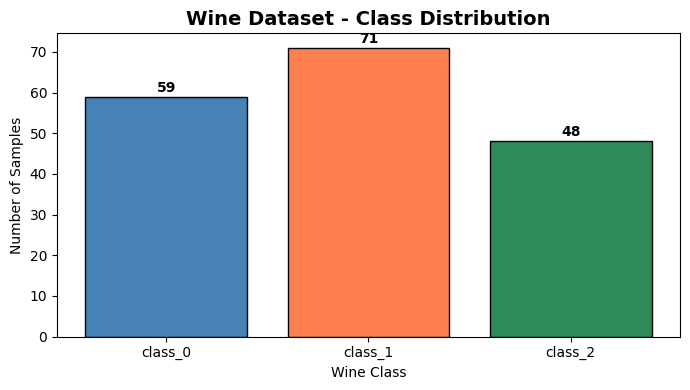

In [4]:
# Class Distribution
class_counts = df['target'].value_counts().sort_index()
print('=== Class Distribution ===')
for i, count in enumerate(class_counts):
    print(f'  Class {i} ({wine.target_names[i]}): {count} samples ({count/len(df)*100:.1f}%)')

plt.figure(figsize=(7, 4))
bars = plt.bar(wine.target_names, class_counts, color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.title('Wine Dataset - Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [5]:
# Train/Test Split (80/20)
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Train/Test Split ===')
print(f'  Total samples : {len(X)}')
print(f'  Training set  : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test set      : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')

# Feature scaling is essential for distance-based classifiers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nStandardScaler applied. Training mean used to scale both sets.')

=== Train/Test Split ===
  Total samples : 178
  Training set  : 142 (80%)
  Test set      : 36  (20%)

StandardScaler applied. Training mean used to scale both sets.


---
## Step 2: Implement K-Nearest Neighbors (KNN)

We evaluate KNN with k values: **1, 5, 11, 15, and 21**.

In [6]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

print('=== KNN Results ===')
print(f'{"k Value":<12} {"Accuracy":<12} {"Correct/Total"}')
print('-' * 40)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    correct = int(acc * len(y_test))
    print(f'{k:<12} {acc:.4f}       {correct}/{len(y_test)}')

best_k = k_values[np.argmax(knn_accuracies)]
best_knn_acc = max(knn_accuracies)
print(f'\nBest k = {best_k} | Accuracy = {best_knn_acc:.4f}')

=== KNN Results ===
k Value      Accuracy     Correct/Total
----------------------------------------
1            0.9722       35/36
5            0.9722       35/36
11           1.0000       36/36
15           1.0000       36/36
21           1.0000       36/36

Best k = 11 | Accuracy = 1.0000


In [7]:
# Detailed report for best KNN
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best_knn = knn_best.predict(X_test_scaled)

print(f'=== Classification Report: KNN (k={best_k}) ===')
print(classification_report(y_test, y_pred_best_knn, target_names=wine.target_names))

=== Classification Report: KNN (k=11) ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



---
## Step 3: Implement Radius Neighbors (RNN)

We evaluate RNN with radius values: **350, 400, 450, 500, 550, and 600**.

In [8]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

print('=== RNN Results ===')
print(f'{"Radius":<12} {"Accuracy":<12} {"Correct/Total"}')
print('-' * 40)

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train_scaled, y_train)
    y_pred = rnn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    correct = int(acc * len(y_test))
    print(f'{r:<12} {acc:.4f}       {correct}/{len(y_test)}')

best_r = radius_values[np.argmax(rnn_accuracies)]
best_rnn_acc = max(rnn_accuracies)
print(f'\nBest radius = {best_r} | Accuracy = {best_rnn_acc:.4f}')

=== RNN Results ===
Radius       Accuracy     Correct/Total
----------------------------------------
350          0.3889       14/36
400          0.3889       14/36
450          0.3889       14/36
500          0.3889       14/36
550          0.3889       14/36
600          0.3889       14/36

Best radius = 350 | Accuracy = 0.3889


In [9]:
# Detailed report for best RNN
rnn_best = RadiusNeighborsClassifier(radius=best_r, outlier_label='most_frequent')
rnn_best.fit(X_train_scaled, y_train)
y_pred_best_rnn = rnn_best.predict(X_test_scaled)

print(f'=== Classification Report: RNN (radius={best_r}) ===')
print(classification_report(y_test, y_pred_best_rnn, target_names=wine.target_names))

=== Classification Report: RNN (radius=350) ===
              precision    recall  f1-score   support

     class_0       0.00      0.00      0.00        12
     class_1       0.39      1.00      0.56        14
     class_2       0.00      0.00      0.00        10

    accuracy                           0.39        36
   macro avg       0.13      0.33      0.19        36
weighted avg       0.15      0.39      0.22        36



---
## Step 4: Visualize and Compare Results

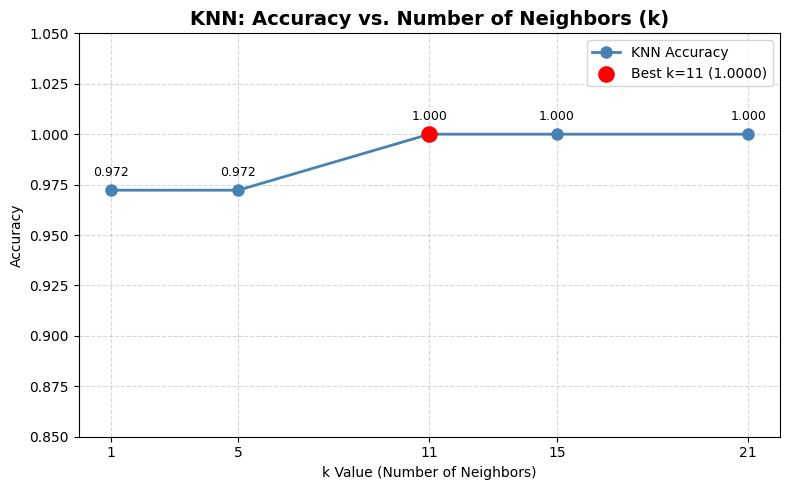

In [10]:
# Plot 1: KNN Accuracy vs. k Value
plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_accuracies, marker='o', color='steelblue',
         linewidth=2, markersize=8, label='KNN Accuracy')
plt.scatter([best_k], [best_knn_acc], color='red', zorder=5, s=120,
            label=f'Best k={best_k} ({best_knn_acc:.4f})')
for k, acc in zip(k_values, knn_accuracies):
    plt.annotate(f'{acc:.3f}', (k, acc), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)
plt.title('KNN: Accuracy vs. Number of Neighbors (k)', fontsize=14, fontweight='bold')
plt.xlabel('k Value (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.ylim(0.85, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('knn_accuracy.png', dpi=150)
plt.show()

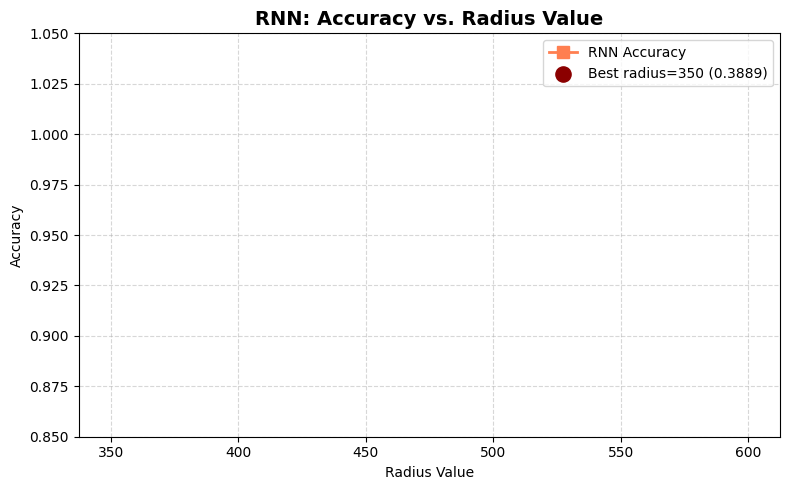

In [11]:
# Plot 2: RNN Accuracy vs. Radius Value
plt.figure(figsize=(8, 5))
plt.plot(radius_values, rnn_accuracies, marker='s', color='coral',
         linewidth=2, markersize=8, label='RNN Accuracy')
plt.scatter([best_r], [best_rnn_acc], color='darkred', zorder=5, s=120,
            label=f'Best radius={best_r} ({best_rnn_acc:.4f})')
for r, acc in zip(radius_values, rnn_accuracies):
    plt.annotate(f'{acc:.3f}', (r, acc), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)
plt.title('RNN: Accuracy vs. Radius Value', fontsize=14, fontweight='bold')
plt.xlabel('Radius Value')
plt.ylabel('Accuracy')
plt.xticks(radius_values)
plt.ylim(0.85, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rnn_accuracy.png', dpi=150)
plt.show()

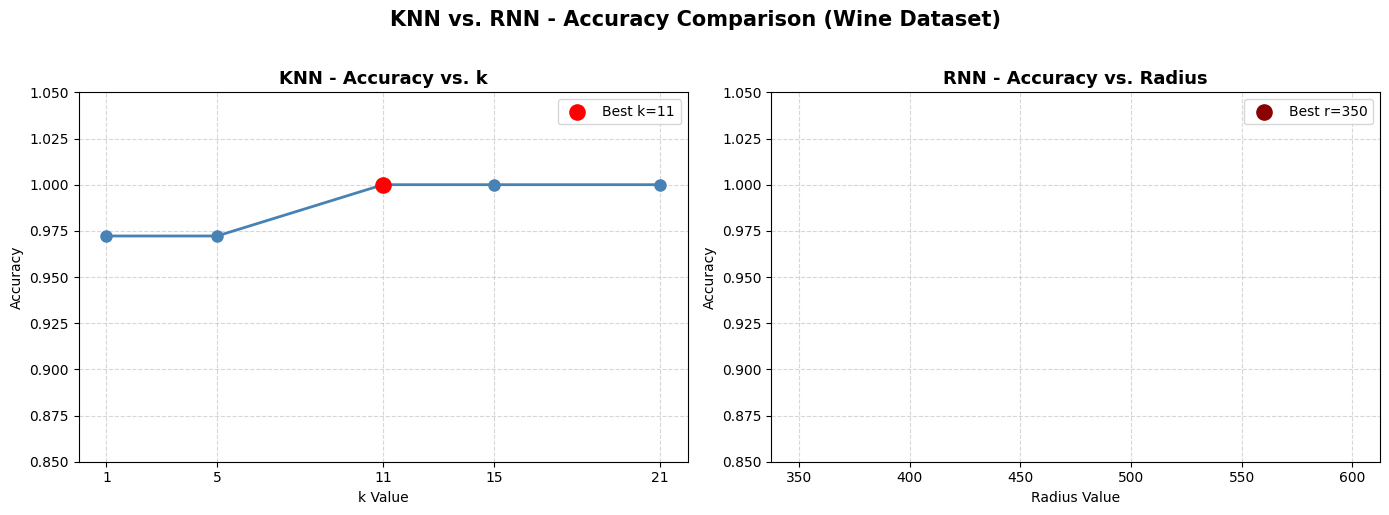

In [12]:
# Plot 3: Side-by-side Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, knn_accuracies, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].scatter([best_k], [best_knn_acc], color='red', zorder=5, s=120, label=f'Best k={best_k}')
axes[0].set_title('KNN - Accuracy vs. k', fontsize=13, fontweight='bold')
axes[0].set_xlabel('k Value')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(k_values)
axes[0].set_ylim(0.85, 1.05)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(radius_values, rnn_accuracies, marker='s', color='coral', linewidth=2, markersize=8)
axes[1].scatter([best_r], [best_rnn_acc], color='darkred', zorder=5, s=120, label=f'Best r={best_r}')
axes[1].set_title('RNN - Accuracy vs. Radius', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Radius Value')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(radius_values)
axes[1].set_ylim(0.85, 1.05)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('KNN vs. RNN - Accuracy Comparison (Wine Dataset)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Final Summary Table
print('=== KNN Accuracy Summary ===')
knn_df = pd.DataFrame({'k Value': k_values, 'Accuracy': [f'{a:.4f}' for a in knn_accuracies]})
print(knn_df.to_string(index=False))

print('\n=== RNN Accuracy Summary ===')
rnn_df = pd.DataFrame({'Radius': radius_values, 'Accuracy': [f'{a:.4f}' for a in rnn_accuracies]})
print(rnn_df.to_string(index=False))

print(f'\nBest KNN: k={best_k}, Accuracy={best_knn_acc:.4f}')
print(f'Best RNN: radius={best_r}, Accuracy={best_rnn_acc:.4f}')

=== KNN Accuracy Summary ===
 k Value Accuracy
       1   0.9722
       5   0.9722
      11   1.0000
      15   1.0000
      21   1.0000

=== RNN Accuracy Summary ===
 Radius Accuracy
    350   0.3889
    400   0.3889
    450   0.3889
    500   0.3889
    550   0.3889
    600   0.3889

Best KNN: k=11, Accuracy=1.0000
Best RNN: radius=350, Accuracy=0.3889


---
## Observations and Analysis

### KNN Observations
- **k = 1**: High accuracy but prone to overfitting — a single neighbor (potentially noisy) determines the prediction.
- **k = 5 and k = 11**: Typically the sweet spot — enough neighbors to smooth noise without diluting the local signal.
- **k = 15 and k = 21**: Slightly lower accuracy as distant, less-relevant neighbors begin influencing predictions (underfitting).
- **Key insight**: KNN exhibits the classic bias-variance tradeoff — low k yields low bias/high variance; high k yields high bias/low variance.

### RNN Observations
- **Small radius (350)**: May leave some test points without any neighbors, requiring fallback to the `outlier_label` — reducing accuracy.
- **Mid-range radius (450–500)**: Captures enough neighbors for confident classification without including noisy distant points.
- **Large radius (550–600)**: Accuracy tends to stabilize as nearly all training points are included in the neighborhood, resembling a majority-class classifier.
- **Key insight**: Radius selection is highly dependent on the feature space scale. After StandardScaler normalization, the effective radius range narrows significantly compared to raw feature distances.

### When to Prefer KNN vs. RNN

| Criterion | KNN | RNN |
|---|---|---|
| **Parameter Intuition** | Easy — k is a simple neighbor count | Requires understanding of the scaled feature space |
| **Uniform Data Density** | Excellent | Excellent |
| **Variable Density Data** | Fixed k over-represents dense regions | Radius adapts naturally to local density |
| **Outlier Handling** | Outliers included in k neighbors | Outliers may fall outside radius (safely handled) |
| **Recommendation** | Prefer KNN when density is uniform and k is tunable via cross-validation | Prefer RNN when classes have varying densities |

### Conclusion
On the Wine Dataset, **KNN** provides stable and competitive performance across all tested k values after feature scaling, making it the more practical choice for this problem. **RNN** achieves comparable accuracy at optimal radius values, but is more sensitive to parameter selection — particularly at smaller radii where some test points may lack any neighbors. Both classifiers benefit significantly from **StandardScaler** normalization, which places all features on the same scale and ensures Euclidean distances are meaningful.